In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mean_bias_error(y_true, y_pred):
    return np.mean(y_true - y_pred)

tickers = ['NKE', 'GS', 'JNJ', 'PFE', 'JPM']
start_date = '2009-04-05'
end_date = '2019-04-06'
train_end = '2017-04-03'
test_start = '2017-04-04'

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


| Company   |   ANN_RMSE |   ANN_MAPE |    ANN_MBE |   RF_RMSE |   RF_MAPE |      RF_MBE |
|:----------|-----------:|-----------:|-----------:|----------:|----------:|------------:|
| NKE       |   1.09675  |    1.25836 | -0.0254601 |  0.737301 |  0.645714 |  0.0161404  |
| GS        |   3.53977  |    1.31285 |  0.63601   |  1.46662  |  0.558337 |  0.239542   |
| JNJ       |   2.55141  |    1.07918 | -0.656237  |  0.756681 |  0.393176 |  0.0485619  |
| PFE       |   0.401846 |    1.05203 | -0.144329  |  0.205752 |  0.428727 | -0.0111635  |
| JPM       |   1.50735  |    1.33934 | -0.738075  |  0.659411 |  0.569212 | -0.00927975 |


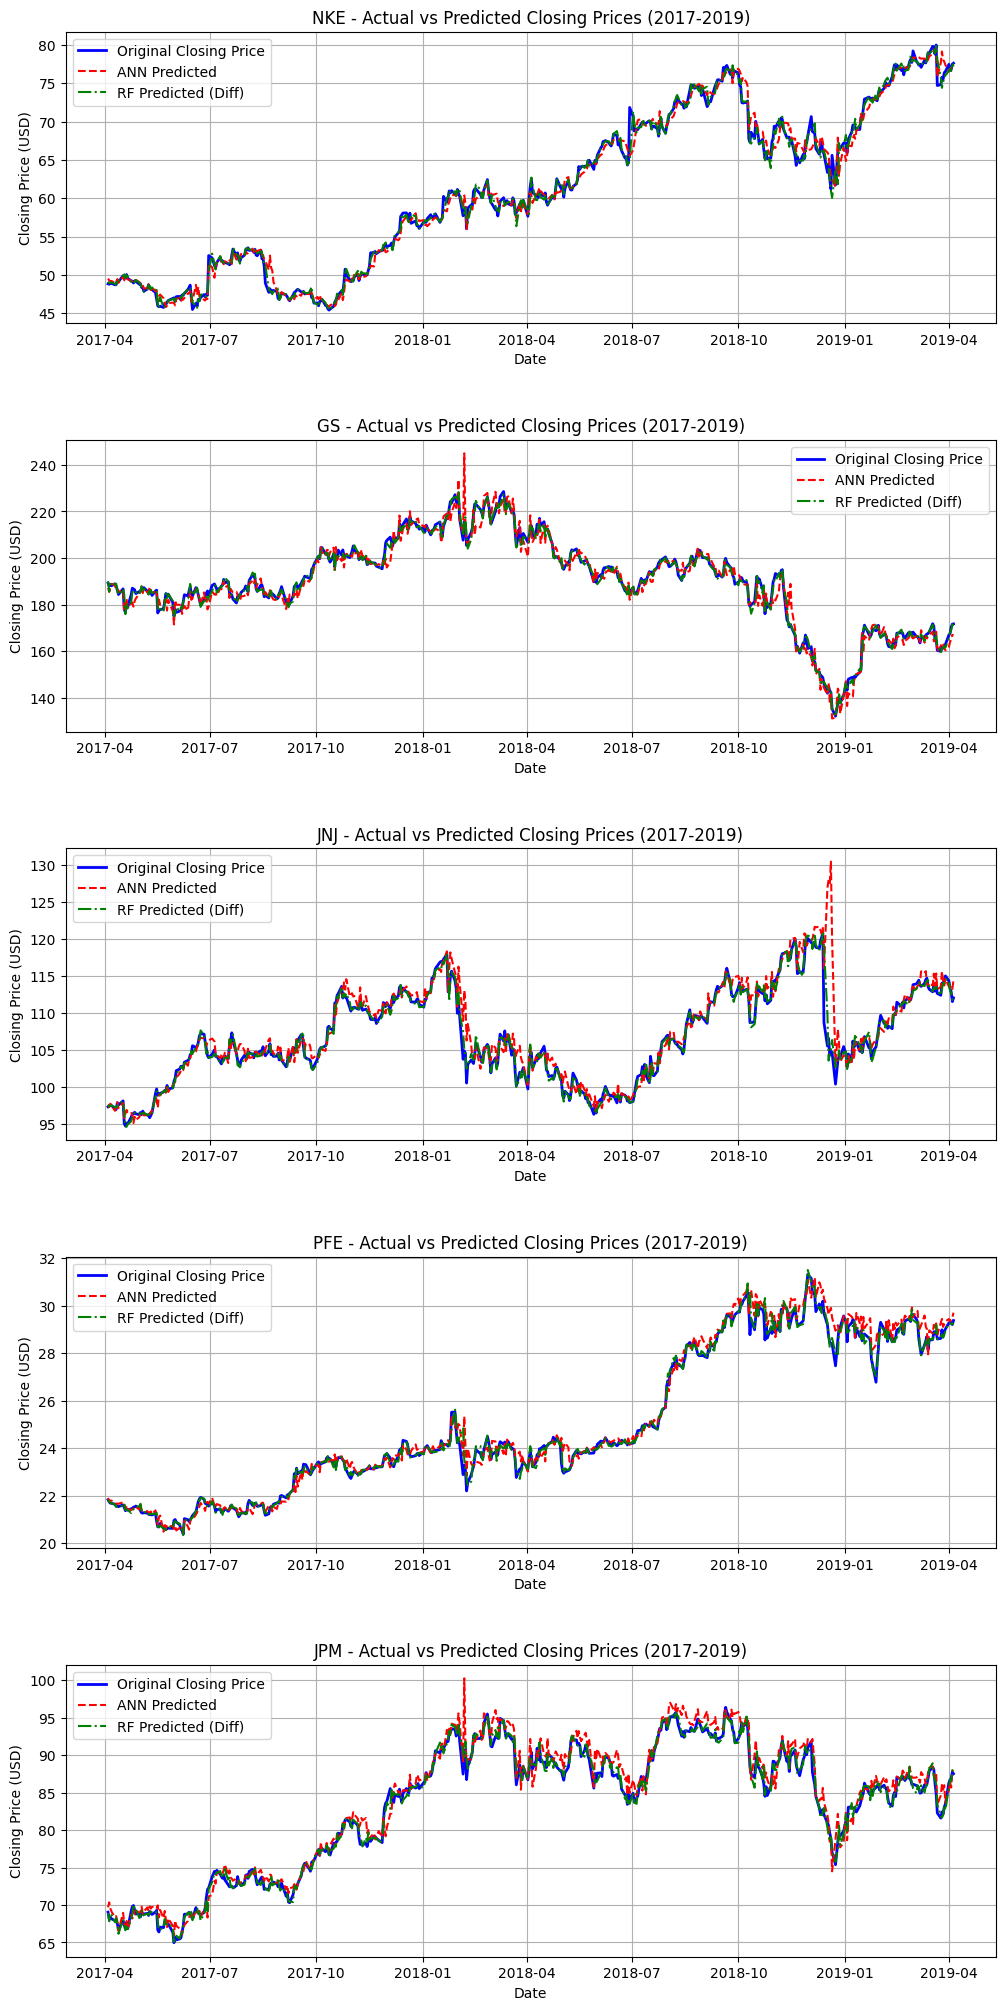

In [3]:
results = []

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 5 * len(tickers)))
plt.subplots_adjust(hspace=0.4)

for idx, ticker in enumerate(tickers):
    df = yf.download(ticker, start=start_date, end=end_date)
    
    df['H-L'] = df['High'] - df['Low']
    df['O-C'] = df['Close'] - df['Open']
    df['7_DAYS_MA'] = df['Close'].rolling(window=7).mean()
    df['14_DAYS_MA'] = df['Close'].rolling(window=14).mean()
    df['21_DAYS_MA'] = df['Close'].rolling(window=21).mean()
    df['7_DAYS_STD_DEV'] = df['Close'].rolling(window=7).std()
    df['Target_Diff'] = df['Close'].diff()
    df['Prev_Close'] = df['Close'].shift(1)
    
    df = df.dropna()
    
    features = ['H-L', 'O-C', '7_DAYS_MA', '14_DAYS_MA', '21_DAYS_MA', '7_DAYS_STD_DEV', 'Volume']
    
    train_df = df.loc[:train_end]
    test_df = df.loc[test_start:]
    
    X_train = train_df[features].values
    y_train_ann = train_df['Close'].values
    y_train_rf = train_df['Target_Diff'].values
    
    X_test = test_df[features].values
    y_test = test_df['Close'].values
    prev_close_test = test_df['Prev_Close'].values
    test_dates = test_df.index
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    ann_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
    ann_model.fit(X_train_scaled, np.ravel(y_train_ann))
    ann_predictions = ann_model.predict(X_test_scaled)
    
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, np.ravel(y_train_rf))
    rf_predictions_diff = rf_model.predict(X_test)
    rf_predictions = prev_close_test + rf_predictions_diff
    
    ann_rmse = np.sqrt(mean_squared_error(y_test, ann_predictions))
    ann_mape = mean_absolute_percentage_error(np.ravel(y_test), ann_predictions)
    ann_mbe = mean_bias_error(np.ravel(y_test), ann_predictions)
    
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_mape = mean_absolute_percentage_error(np.ravel(y_test), rf_predictions)
    rf_mbe = mean_bias_error(np.ravel(y_test), rf_predictions)
    
    results.append({
        'Company': ticker,
        'ANN_RMSE': ann_rmse,
        'ANN_MAPE': ann_mape,
        'ANN_MBE': ann_mbe,
        'RF_RMSE': rf_rmse,
        'RF_MAPE': rf_mape,
        'RF_MBE': rf_mbe
    })
    
    ax = axes[idx]
    ax.plot(test_dates, y_test, label='Original Closing Price', color='blue', linewidth=2)
    ax.plot(test_dates, ann_predictions, label='ANN Predicted', color='red', linestyle='--')
    ax.plot(test_dates, rf_predictions, label='RF Predicted (Diff)', color='green', linestyle='-.')
    ax.set_title(f"{ticker} - Actual vs Predicted Closing Prices (2017-2019)")
    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price (USD)')
    ax.legend()
    ax.grid(True)

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))
plt.show()